# Tune + Eigenmode

In [1]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

result True C:\Users\Soske\Documents\git_projects\cavsim2d_simulations cavities
ERROR:: Exception occurred: 
ERROR:: Tune results not found. Please tune the cavity
{'cav_tune_eig': {}}


c:\Users\Soske\Documents\git_projects\cavsim2d\notebooks\..\cavsim2d\cavity\cavities.py:909: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

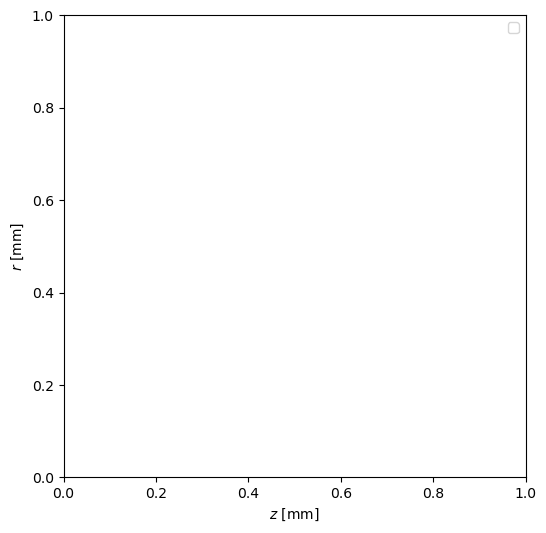

In [10]:
# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_eig = EllipticalCavity(1, midcell, midcell, midcell, beampipe='none')
ax = cav_tune_eig.plot('geometry', label='Before tuning')

cavs_tune_eig = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

cavs_tune_eig.add_cavity(cav_tune_eig, 'cav_tune_eig')

tune_config = {
    'freqs': 801.58,
    'parameters': 'L_el',
    'cell_types': 'mid-cell',
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
    },
}
cavs_tune_eig.run_tune(tune_config)
pp.pprint(cavs_tune_eig.tune_results)

# plot geometry after tuning
cavs_tune_eig.plot('geometry', ax, label='After tuning')

In [ ]:
ax_obj_dict = cavs_tune_eig.save_plot_as_json(ax)

In [ ]:
cavs_tune_eig.plot_from_json(ax_obj_dict)

In [ ]:
cavs_tune_eig.plot('convergence')
plt.show()

# Tune (+UQ) + Eigenmode

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_uq_eig = EllipticalCavity(1, midcell, endcell, endcell, beampipe='both')
ax = cav_tune_uq_eig.plot('geometry', label='Before tuning')

cavs_tune_uq_eig = Cavities()
cavs_tune_uq_eig.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')

cavs_tune_uq_eig.add_cavity(cav_tune_uq_eig, 'cav_tune_uq_eig')

tune_config = {
    'freqs': 801.58,
    'parameters': 'Req',
    'cell_types': 'mid-cell',
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
    },
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'objectives': ["freq [MHz]"],
        'processes': 4,
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs_tune_uq_eig.run_tune(tune_config)
pp.pprint(cavs_tune_uq_eig.tune_results)

# plot geometry after tuning
cavs_tune_uq_eig.plot('geometry', ax, label='After tuning')

# Tune + Eigenmode (+UQ)

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_eig_uq = EllipticalCavity(1, midcell, endcell, endcell, beampipe='both')
ax = cav_tune_eig_uq.plot('geometry', label='Before tuning')

cavs_tune_eig_uq = Cavities()
cavs_tune_eig_uq.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')

cavs_tune_eig_uq.add_cavity(cav_tune_eig_uq, 'cav_tune_eig_uq')

tune_config = {
    'freqs': 801.58,
    'parameters': 'Req',
    'cell_types': 'mid-cell',
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
        'uq_config': {
            'variables': ['A', 'B', 'a', 'b'],
            'objectives': ["freq [MHz]", "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
            'delta': [0.05, 0.05, 0.05, 0.05],
            'processes': 4,
            'distribution': 'gaussian',
            'method': ['Quadrature', 'Stroud3'],
            'cell_type': 'mid-cell',
            'cell complexity': 'simplecell'
            }
    },
}
cavs_tune_eig_uq.run_tune(tune_config)
pp.pprint(cavs_tune_eig_uq.tune_results)

# plot geometry after tuning
cavs_tune_eig_uq.plot('geometry', ax, label='After tuning')

# Tune (+UQ) + Eigenmode (+UQ)

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_uq_eig_uq = EllipticalCavity(1, midcell, endcell, endcell, beampipe='both')
ax = cav_tune_uq_eig_uq.plot('geometry', label='Before tuning')

cavs_tune_uq_eig_uq = Cavities()
cavs_tune_uq_eig_uq.save('D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')

cavs_tune_uq_eig_uq.add_cavity(cav_tune_uq_eig_uq, 'cav_tune_uq_eig_uq')

tune_config = {
    'freqs': 801.58,
    'parameters': 'Req',
    'cell_types': 'mid-cell',
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
        'uq_config': {
            'variables': ['A', 'B', 'a', 'b'],
            'objectives': ["freq [MHz]", "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
            'delta': [0.05, 0.05, 0.05, 0.05],
            'processes': 4,
            'distribution': 'gaussian',
            'method': ['Quadrature', 'Stroud3'],
            'cell_type': 'mid-cell',
            'cell complexity': 'simplecell'
            }
    },
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'objectives': ["freq [MHz]"],
        'processes': 4,
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs_tune_uq_eig_uq.run_tune(tune_config)
pp.pprint(cavs_tune_uq_eig_uq.tune_results)

# plot geometry after tuning
cavs_tune_uq_eig_uq.plot('geometry', ax, label='After tuning')